In [1]:
import pandas as pd

# Cargar todas las tablas
customers = pd.read_csv('../data/olist_customers_dataset.csv')
geolocation = pd.read_csv('../data/olist_geolocation_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
orders = pd.read_csv('../data/olist_orders_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
category_translation = pd.read_csv('../data/product_category_name_translation.csv')

# Diccionario para iterar fácilmente
tablas = {
    'customers': customers,
    'geolocation': geolocation,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'orders': orders,
    'products': products,
    'sellers': sellers,
    'category_translation': category_translation
}

for nombre, df in tablas.items():
    print(f"{nombre}: {df.shape[0]} filas, {df.shape[1]} columnas")

customers: 99441 filas, 5 columnas
geolocation: 1000163 filas, 5 columnas
order_items: 112650 filas, 7 columnas
payments: 103886 filas, 5 columnas
reviews: 99224 filas, 7 columnas
orders: 99441 filas, 8 columnas
products: 32951 filas, 9 columnas
sellers: 3095 filas, 4 columnas
category_translation: 71 filas, 2 columnas


In [2]:
for nombre, df in tablas.items():
    print(f"\n{'='*50}")
    print(f"TABLA: {nombre}")
    print(f"{'='*50}")
    print(df.dtypes)
    print("\nValores nulos por columna:")
    nulos = df.isnull().sum()
    print(nulos[nulos > 0] if nulos.sum() > 0 else "Sin valores nulos")


TABLA: customers
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

Valores nulos por columna:
Sin valores nulos

TABLA: geolocation
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object

Valores nulos por columna:
Sin valores nulos

TABLA: order_items
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

Valores nulos por columna:
Sin valores nulos

TABLA: payments
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float6

In [3]:
# ¿Los nulos en fechas de entrega corresponden a pedidos no entregados?
print(orders[orders['order_delivered_customer_date'].isnull()]['order_status'].value_counts())

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


In [4]:
# Inconsistencia: pedidos "delivered" sin fecha de entrega registrada
inconsistencias = orders[
    (orders['order_status'] == 'delivered') & 
    (orders['order_delivered_customer_date'].isnull())
]
print(f"Pedidos inconsistentes: {len(inconsistencias)}")
inconsistencias[['order_id', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date']]

Pedidos inconsistentes: 8


,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,NaN
20618,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,NaN
43834,2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,NaN
79263,e69f75a717d64fc5ecdfae42b2e8e086,delivered,2018-07-01 22:05:55,NaN
82868,0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,NaN
92643,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,NaN
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,delivered,2018-06-08 12:09:39,NaN
98038,20edc82cf5400ce95e1afacc25798b31,delivered,2018-06-27 16:09:12,NaN


## Hallazgo: Inconsistencia en fechas de entrega

8 pedidos (0.008% del total) tienen status "delivered" pero carecen de 
`order_delivered_customer_date`. Notablemente, 3 de estos casos ocurren 
el mismo día (2018-07-01), lo que sugiere un posible problema puntual 
del sistema en esa fecha — aunque no se puede confirmar la causa exacta 
con los datos disponibles. Estos registros se excluirán de análisis que 
dependan específicamente de tiempos de entrega, pero se conservan para 
el resto del análisis.

In [5]:
# ¿Cuánto volumen de ventas representan los productos con categoría nula?
productos_incompletos = products[products['product_category_name'].isnull()]['product_id']
items_afectados = order_items[order_items['product_id'].isin(productos_incompletos)]

print(f"Productos con metadata incompleta: {len(productos_incompletos)}")
print(f"Items de pedidos afectados: {len(items_afectados)}")
print(f"% del total de items: {len(items_afectados) / len(order_items) * 100:.2f}%")

Productos con metadata incompleta: 610
Items de pedidos afectados: 1603
% del total de items: 1.42%


In [6]:
# Imputación de products
products['product_category_name'] = products['product_category_name'].fillna('sem_categoria')
products['product_name_lenght'] = products['product_name_lenght'].fillna(0)
products['product_description_lenght'] = products['product_description_lenght'].fillna(0)
products['product_photos_qty'] = products['product_photos_qty'].fillna(0)

# Los 2 nulos de dimensiones físicas: imputamos con la mediana
for col in ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']:
    products[col] = products[col].fillna(products[col].median())

# Verifica que ya no queden nulos
print(products.isnull().sum().sum())

0


In [7]:
# Empezamos con orders como tabla base
df = orders.merge(order_items, on='order_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(sellers, on='seller_id', how='left')
df = df.merge(category_translation, on='product_category_name', how='left')

# Payments: un pedido puede tener varios pagos (ej. tarjeta + voucher),
# así que agregamos por order_id para no duplicar filas
payments_agg = payments.groupby('order_id').agg(
    payment_value_total=('payment_value', 'sum'),
    payment_type_principal=('payment_type', 'first'),
    payment_installments_max=('payment_installments', 'max')
).reset_index()
df = df.merge(payments_agg, on='order_id', how='left')

# Reviews: un pedido normalmente tiene un solo review, pero por seguridad
# tomamos el primero si hubiera duplicados
reviews_dedup = reviews.drop_duplicates(subset='order_id', keep='first')
df = df.merge(
    reviews_dedup[['order_id', 'review_score']], 
    on='order_id', 
    how='left'
)

print(f"DataFrame maestro: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

DataFrame maestro: 113425 filas, 34 columnas


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,payment_value_total,payment_type_principal,payment_installments_max,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,sao paulo,SP,9350.0,maua,SP,housewares,38.71,credit_card,1.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,barreiras,BA,31570.0,belo horizonte,SP,perfumery,141.46,boleto,1.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,vianopolis,GO,14840.0,guariba,SP,auto,179.12,credit_card,3.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,sao goncalo do amarante,RN,31842.0,belo horizonte,MG,pet_shop,72.20,credit_card,1.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,santo andre,SP,8752.0,mogi das cruzes,SP,stationery,28.62,credit_card,1.0,5.0


In [8]:
# Verificar unicidad de las llaves de merge en cada tabla
print("products - product_id únicos vs total filas:", products['product_id'].nunique(), "/", len(products))
print("customers - customer_id únicos vs total filas:", customers['customer_id'].nunique(), "/", len(customers))
print("sellers - seller_id únicos vs total filas:", sellers['seller_id'].nunique(), "/", len(sellers))
print("category_translation - product_category_name únicos vs total filas:", category_translation['product_category_name'].nunique(), "/", len(category_translation))

products - product_id únicos vs total filas: 32951 / 32951
customers - customer_id únicos vs total filas: 99441 / 99441
sellers - seller_id únicos vs total filas: 3095 / 3095
category_translation - product_category_name únicos vs total filas: 71 / 71


In [9]:
print("orders - order_id únicos vs total filas:", orders['order_id'].nunique(), "/", len(orders))
print("order_items - order_id repetidos (normal) pero verificamos función distinta:")
print("order_items total filas:", len(order_items))
print("order_items - combinación order_id + order_item_id única:", 
      order_items.duplicated(subset=['order_id', 'order_item_id']).sum(), "duplicados")

orders - order_id únicos vs total filas: 99441 / 99441
order_items - order_id repetidos (normal) pero verificamos función distinta:
order_items total filas: 112650
order_items - combinación order_id + order_item_id única: 0 duplicados


In [10]:
ordenes_sin_items = set(orders['order_id']) - set(order_items['order_id'])
print(f"Pedidos en 'orders' sin ningún item en 'order_items': {len(ordenes_sin_items)}")

Pedidos en 'orders' sin ningún item en 'order_items': 775


In [11]:
# ¿Qué status tienen los pedidos sin items?
print(orders[orders['order_id'].isin(ordenes_sin_items)]['order_status'].value_counts())

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


## Hallazgo: Pedidos sin items asociados

775 pedidos (0.78% del total) no tienen ningún registro en `order_items`. 
Esto se debe a que el merge orders→order_items es 'left join', preservando 
pedidos que probablemente se cancelaron o quedaron indisponibles antes de 
procesarse. Estas filas se conservan en el DataFrame maestro con valores 
nulos en las columnas de producto/precio, y se excluirán de análisis 
específicos de ventas (donde no aplican), pero se mantienen para análisis 
de tasa de cancelación.

# ¿Hay estacionalidad que Olist debería anticipar?

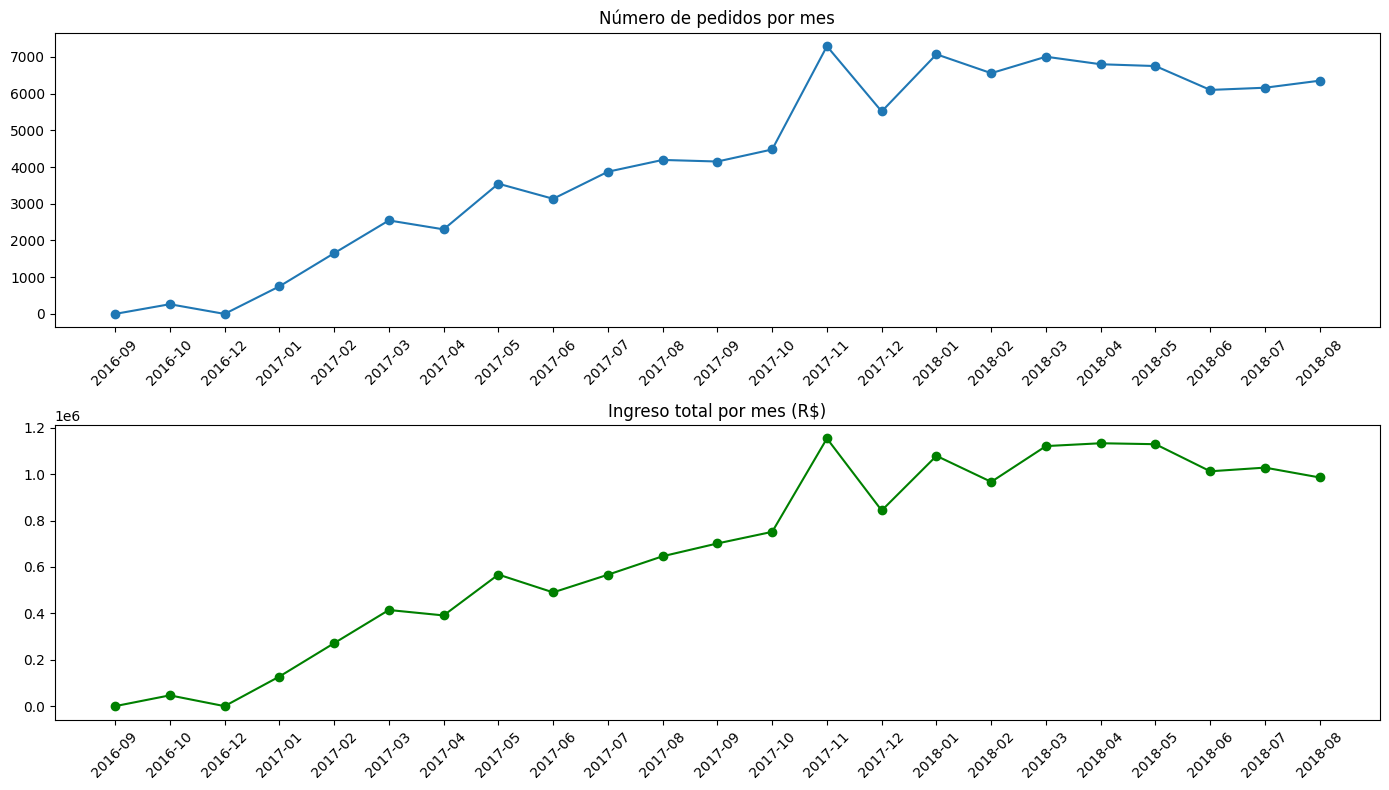

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Solo pedidos con status delivered, para medir ventas reales concretadas
df_delivered = df[df['order_status'] == 'delivered'].copy()

# Convertir a datetime
df_delivered['order_purchase_timestamp'] = pd.to_datetime(df_delivered['order_purchase_timestamp'])
df_delivered['year_month'] = df_delivered['order_purchase_timestamp'].dt.to_period('M')

# Ventas por mes, a nivel pedido único (evitar duplicar por múltiples items)
ventas_mensuales = df_delivered.drop_duplicates(subset='order_id').groupby('year_month').agg(
    num_pedidos=('order_id', 'count'),
    ingreso_total=('payment_value_total', 'sum')
).reset_index()

ventas_mensuales['year_month'] = ventas_mensuales['year_month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(ventas_mensuales['year_month'], ventas_mensuales['num_pedidos'], marker='o')
axes[0].set_title('Número de pedidos por mes')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(ventas_mensuales['year_month'], ventas_mensuales['ingreso_total'], marker='o', color='green')
axes[1].set_title('Ingreso total por mes (R$)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [13]:
print("Rango de fechas en el dataset:")
print(df_delivered['order_purchase_timestamp'].min(), "a", df_delivered['order_purchase_timestamp'].max())

Rango de fechas en el dataset:
2016-09-15 12:16:38 a 2018-08-29 15:00:37


In [14]:
print(df_delivered[df_delivered['year_month'].astype(str) == '2016-11'].shape[0])

0


In [15]:
nov_2017 = df_delivered[df_delivered['order_purchase_timestamp'].dt.to_period('M').astype(str) == '2017-11']
ventas_por_dia = nov_2017.drop_duplicates(subset='order_id').groupby(
    nov_2017['order_purchase_timestamp'].dt.day
)['order_id'].count()
print(ventas_por_dia)

order_purchase_timestamp
1      108
2      117
3      138
4      106
5      137
6      182
7      154
8      169
9      182
10     159
11     152
12     170
13     197
14     184
15     176
16     219
17     185
18     141
19     157
20     219
21     222
22     190
23     268
24    1147
25     487
26     382
27     395
28     372
29     314
30     260
Name: order_id, dtype: int64


## Hallazgo: Estacionalidad confirmada por Black Friday

El pico más alto de todo el periodo analizado ocurre en noviembre 2017,
explicado casi en su totalidad por el 24 de noviembre (Black Friday),
día que concentró 1,147 pedidos frente a un promedio diario de ~200 
pedidos ese mismo mes (~5.7x el promedio). Esto confirma que Olist 
debería anticipar picos de demanda e inventario alrededor de esta fecha 
en años subsecuentes.

Nota: noviembre 2016 registra 0 pedidos entregados, consistente con que 
Olist se encontraba en fase temprana de operación (el dataset inicia en 
septiembre 2016). Agosto 2018 aparece incompleto porque el dataset se 
corta el día 29, no representa una caída real de ventas.

# ¿El tiempo de entrega predice insatisfacción del cliente?

In [16]:
# Filtrar solo pedidos delivered con fecha de entrega válida
df_entrega = df_delivered[df_delivered['order_delivered_customer_date'].notna()].copy()
df_entrega = df_entrega.drop_duplicates(subset='order_id')

df_entrega['order_delivered_customer_date'] = pd.to_datetime(df_entrega['order_delivered_customer_date'])
df_entrega['dias_entrega'] = (
    df_entrega['order_delivered_customer_date'] - df_entrega['order_purchase_timestamp']
).dt.days

# Revisa estadísticas básicas antes de graficar - detecta outliers imposibles
print(df_entrega['dias_entrega'].describe())

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: dias_entrega, dtype: float64


In [17]:
# Revisa los casos más extremos
print(df_entrega.nlargest(10, 'dias_entrega')[['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date', 'dias_entrega', 'customer_state']])

# Método IQR para detectar outliers de forma objetiva, no arbitraria
Q1 = df_entrega['dias_entrega'].quantile(0.25)
Q3 = df_entrega['dias_entrega'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
print(f"\nLímite superior (IQR): {limite_superior:.1f} días")
print(f"Pedidos por encima del límite: {(df_entrega['dias_entrega'] > limite_superior).sum()} ({(df_entrega['dias_entrega'] > limite_superior).sum() / len(df_entrega) * 100:.2f}%)")

                                order_id order_purchase_timestamp  \
22305   ca07593549f1816d26a572e06dc1eab6      2017-02-21 23:31:27   
63368   1b3190b2dfa9d789e1f14c05b647a14a      2018-02-23 14:57:35   
70141   440d0d17af552815d15a9e41abe49359      2017-03-07 23:59:51   
43885   0f4519c5f1c541ddec9f21b3bddd533a      2017-03-09 13:26:57   
80140   2fb597c2f772eca01b1f5c561bf6cc7b      2017-03-08 18:09:02   
101553  285ab9426d6982034523a855f55a885e      2017-03-08 22:47:40   
12911   47b40429ed8cce3aee9199792275433f      2018-01-03 09:44:01   
92704   2fe324febf907e3ea3f2aa9650869fa5      2017-03-13 20:17:10   
62088   2d7561026d542c8dbd8f0daeadf67a43      2017-03-15 11:24:27   
70900   437222e3fd1b07396f1d9ba8c15fba59      2017-03-16 11:36:00   

       order_delivered_customer_date  dias_entrega customer_state  
22305            2017-09-19 14:36:39           209             ES  
63368            2018-09-19 23:24:07           208             RJ  
70141            2017-09-19 15:12:50

In [18]:
# ¿Cuántos pedidos en todo el dataset se marcaron como entregados justo ese día?
entregas_19_sep = df_entrega[df_entrega['order_delivered_customer_date'].dt.date.astype(str) == '2017-09-19']
print(f"Total de pedidos con fecha de entrega 2017-09-19: {len(entregas_19_sep)}")
print(f"\nDistribución de sus fechas de compra:")
print(entregas_19_sep['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index())

Total de pedidos con fecha de entrega 2017-09-19: 282

Distribución de sus fechas de compra:
order_purchase_timestamp
2017-02      1
2017-03     11
2017-04      7
2017-05      2
2017-06      3
2017-07      7
2017-08     47
2017-09    204
Freq: M, Name: count, dtype: int64


In [19]:
# El grupo anómalo real: compra 2+ meses antes de esta fecha de entrega masiva
pedidos_anomalos = entregas_19_sep[
    entregas_19_sep['order_purchase_timestamp'] < '2017-08-01'
]
print(f"Pedidos con retraso anómalo real: {len(pedidos_anomalos)}")

# Excluir estos del análisis de tiempo de entrega (no del dataset completo)
ids_anomalos = pedidos_anomalos['order_id'].tolist()
df_entrega_limpio = df_entrega[~df_entrega['order_id'].isin(ids_anomalos)]

print(f"Dataset original: {len(df_entrega)} filas")
print(f"Dataset limpio para análisis de entrega: {len(df_entrega_limpio)} filas")

Pedidos con retraso anómalo real: 31
Dataset original: 96470 filas
Dataset limpio para análisis de entrega: 96439 filas


## Hallazgo: Lote de entregas rezagadas (19 sept 2017)

Se identificaron 31 pedidos comprados entre febrero y julio 2017 que 
comparten fecha de entrega (19 sept 2017), sugiriendo un problema 
sistémico de logística o registro que retuvo estos pedidos por meses. 
Estos 31 casos se excluyen del análisis de tiempo de entrega (no del 
dataset completo) por no ser representativos del proceso normal de 
Olist, evitando que distorsionen la correlación entrega-satisfacción.

In [20]:
from scipy import stats

# Filtrar juntas ambas columnas para garantizar mismo tamaño
datos_correlacion = df_entrega_limpio[['dias_entrega', 'review_score']].dropna()

print(f"Filas usadas en la correlación: {len(datos_correlacion)}")

correlacion, p_valor = stats.pearsonr(
    datos_correlacion['dias_entrega'], 
    datos_correlacion['review_score']
)

print(f"Correlación de Pearson: {correlacion:.3f}")
print(f"P-valor: {p_valor:.10f}")

Filas usadas en la correlación: 95795
Correlación de Pearson: -0.341
P-valor: 0.0000000000


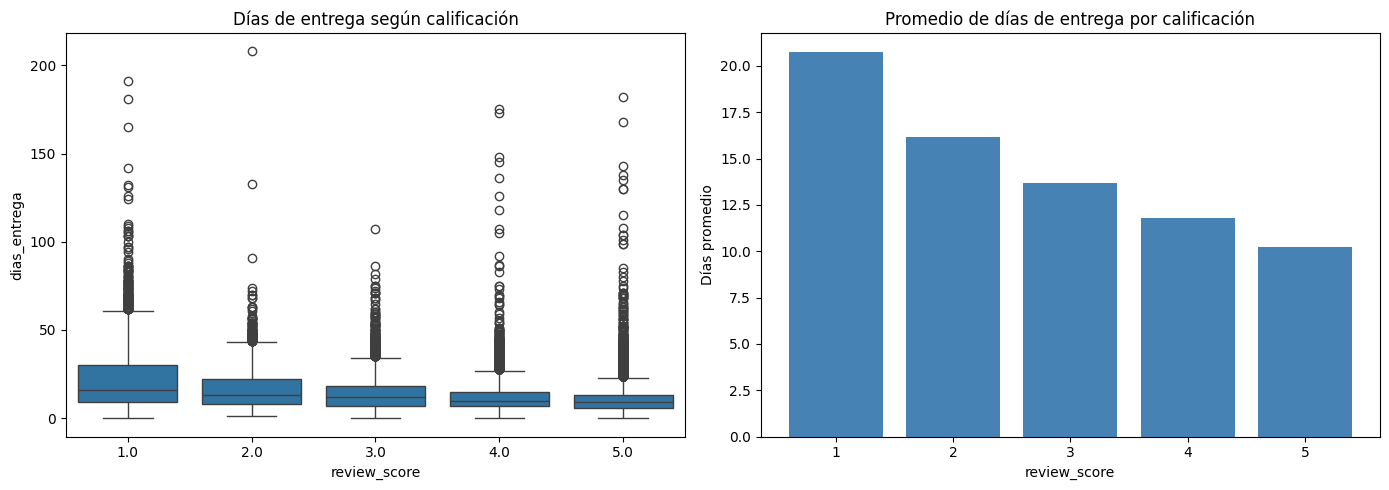

review_score
1.0    20.746732
2.0    16.137624
3.0    13.694089
4.0    11.792820
5.0    10.205808
Name: dias_entrega, dtype: float64


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: distribución de días de entrega por score
sns.boxplot(data=df_entrega_limpio, x='review_score', y='dias_entrega', ax=axes[0])
axes[0].set_title('Días de entrega según calificación')

# Promedio de días de entrega por score
promedio_por_score = df_entrega_limpio.groupby('review_score')['dias_entrega'].mean()
axes[1].bar(promedio_por_score.index, promedio_por_score.values, color='steelblue')
axes[1].set_title('Promedio de días de entrega por calificación')
axes[1].set_xlabel('review_score')
axes[1].set_ylabel('Días promedio')

plt.tight_layout()
plt.show()

print(promedio_por_score)

## Hallazgo: El tiempo de entrega SÍ influye en la satisfacción, pero no es el único factor

Se encontró una correlación negativa de magnitud moderada entre días de 
entrega y calificación del cliente (Pearson r = -0.341, p < 0.001, n = 95,795). 
Los pedidos calificados con 1 estrella tardaron en promedio 20.7 días en 
entregarse, más del doble que los calificados con 5 estrellas (10.2 días).

Sin embargo, la correlación moderada (no fuerte) y la alta dispersión visible 
en los boxplots indican que el tiempo de entrega es un factor relevante pero 
no el único determinante de la satisfacción — hay pedidos con entregas muy 
rápidas y baja calificación, y viceversa. Se recomienda investigar otros 
factores (calidad del producto, comunicación, expectativa vs realidad de 
fecha estimada) en análisis futuros.

**Recomendación de negocio**: reducir tiempos de entrega por encima de 15-20 
días debería tener impacto medible en satisfacción, pero no es garantía por 
sí sola de mejorar reviews bajos.

# ¿Qué regiones están sub-atendidas vs su potencial de mercado?

In [22]:
# Ventas por estado del cliente
ventas_por_estado = df_delivered.drop_duplicates(subset='order_id').groupby('customer_state').agg(
    num_pedidos=('order_id', 'count'),
    ingreso_total=('payment_value_total', 'sum'),
    review_promedio=('review_score', 'mean')
).reset_index().sort_values('num_pedidos', ascending=False)

print(ventas_por_estado)

   customer_state  num_pedidos  ingreso_total  review_promedio
25             SP        40501     5770266.19         4.246617
18             RJ        12350     2055690.45         3.964950
10             MG        11354     1819277.61         4.192645
22             RS         5345      861802.40         4.186033
17             PR         4923      781919.55         4.240408
23             SC         3546      595208.40         4.132992
4              BA         3256      591270.60         3.930629
6              DF         2080      346146.17         4.132367
7              ES         1995      317682.65         4.080244
8              GO         1957      334294.22         4.103803
15             PE         1593      309074.59         4.082964
5              CE         1279      266463.97         3.944226
13             PA          946      212027.55         3.909968
12             MT          886      181441.72         4.146758
9              MA          717      147807.29         3

In [23]:
import requests

# API oficial del IBGE - Tabla 6579, nivel estadual (N3), variable población, año 2021
url = "https://apisidra.ibge.gov.br/values/t/6579/n3/all/v/9324/p/2021"
response = requests.get(url)
poblacion_ibge = pd.DataFrame(response.json())

print(poblacion_ibge.head(10))
print(f"\nTotal de registros: {len(poblacion_ibge)}")

                           NC                    NN  \
0  Nível Territorial (Código)     Nível Territorial   
1                           3  Unidade da Federação   
2                           3  Unidade da Federação   
3                           3  Unidade da Federação   
4                           3  Unidade da Federação   
5                           3  Unidade da Federação   
6                           3  Unidade da Federação   
7                           3  Unidade da Federação   
8                           3  Unidade da Federação   
9                           3  Unidade da Federação   

                           MC                 MN        V  \
0  Unidade de Medida (Código)  Unidade de Medida    Valor   
1                          45            Pessoas  1815278   
2                          45            Pessoas   906876   
3                          45            Pessoas  4269995   
4                          45            Pessoas   652713   
5                          4

In [24]:
# Eliminar la fila de metadata (fila 0) y quedarnos con columnas relevantes
poblacion_ibge = poblacion_ibge.iloc[1:].copy()
poblacion_ibge = poblacion_ibge[['D1N', 'V']].rename(columns={'D1N': 'estado_nombre', 'V': 'poblacion'})
poblacion_ibge['poblacion'] = poblacion_ibge['poblacion'].astype(int)

print(poblacion_ibge)

          estado_nombre  poblacion
1              Rondônia    1815278
2                  Acre     906876
3              Amazonas    4269995
4               Roraima     652713
5                  Pará    8777124
6                 Amapá     877613
7             Tocantins    1607363
8              Maranhão    7153262
9                 Piauí    3289290
10                Ceará    9240580
11  Rio Grande do Norte    3560903
12              Paraíba    4059905
13           Pernambuco    9674793
14              Alagoas    3365351
15              Sergipe    2338474
16                Bahia   14985284
17         Minas Gerais   21411923
18       Espírito Santo    4108508
19       Rio de Janeiro   17463349
20            São Paulo   46649132
21               Paraná   11597484
22       Santa Catarina    7338473
23    Rio Grande do Sul   11466630
24   Mato Grosso do Sul    2839188
25          Mato Grosso    3567234
26                Goiás    7206589
27     Distrito Federal    3094325


In [25]:
mapeo_estados = {
    'Rondônia': 'RO', 'Acre': 'AC', 'Amazonas': 'AM', 'Roraima': 'RR',
    'Pará': 'PA', 'Amapá': 'AP', 'Tocantins': 'TO', 'Maranhão': 'MA',
    'Piauí': 'PI', 'Ceará': 'CE', 'Rio Grande do Norte': 'RN', 'Paraíba': 'PB',
    'Pernambuco': 'PE', 'Alagoas': 'AL', 'Sergipe': 'SE', 'Bahia': 'BA',
    'Minas Gerais': 'MG', 'Espírito Santo': 'ES', 'Rio de Janeiro': 'RJ',
    'São Paulo': 'SP', 'Paraná': 'PR', 'Santa Catarina': 'SC',
    'Rio Grande do Sul': 'RS', 'Mato Grosso do Sul': 'MS', 'Mato Grosso': 'MT',
    'Goiás': 'GO', 'Distrito Federal': 'DF'
}

poblacion_ibge['customer_state'] = poblacion_ibge['estado_nombre'].map(mapeo_estados)

# Verificar que todos mapearon correctamente (no debe haber NaN)
print(poblacion_ibge['customer_state'].isnull().sum(), "estados sin mapear")

0 estados sin mapear


In [26]:
analisis_regional = ventas_por_estado.merge(poblacion_ibge[['customer_state', 'poblacion']], on='customer_state')

# Pedidos por cada 100,000 habitantes - la métrica clave para comparar "potencial vs realidad"
analisis_regional['pedidos_por_100k_hab'] = (analisis_regional['num_pedidos'] / analisis_regional['poblacion']) * 100000

analisis_regional = analisis_regional.sort_values('pedidos_por_100k_hab', ascending=False)
print(analisis_regional[['customer_state', 'num_pedidos', 'poblacion', 'pedidos_por_100k_hab']])

   customer_state  num_pedidos  poblacion  pedidos_por_100k_hab
0              SP        40501   46649132             86.820479
1              RJ        12350   17463349             70.719540
7              DF         2080    3094325             67.219830
2              MG        11354   21411923             53.026531
8              ES         1995    4108508             48.557773
5              SC         3546    7338473             48.320679
3              RS         5345   11466630             46.613521
4              PR         4923   11597484             42.448862
9              GO         1957    7206589             27.155704
13             MT          886    3567234             24.837171
15             MS          701    2839188             24.690158
6              BA         3256   14985284             21.727983
21             TO          274    1607363             17.046554
10             PE         1593    9674793             16.465469
17             PI          476    328929

In [27]:
# ¿Dónde están concentrados los vendedores?
distribucion_sellers = sellers['seller_state'].value_counts()
print(distribucion_sellers)
print(f"\n% de sellers en SP: {(distribucion_sellers.get('SP', 0) / len(sellers) * 100):.1f}%")

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
MS       5
RN       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

% de sellers en SP: 59.7%


## Hallazgo: Concentración geográfica de vendedores explica baja penetración regional

Los estados del Norte y Nordeste de Brasil (especialmente Amazonas, Pará, 
Maranhão, Roraima) muestran la menor penetración de mercado relativa a su 
población (pedidos por 100k habitantes), a pesar de tener poblaciones 
considerables (Amazonas: 4.27M habitantes, solo 3.4 pedidos/100k).

Esta brecha coincide con una concentración extrema de vendedores en el 
Sureste: 59.7% de todos los sellers de la plataforma están en São Paulo, 
mientras que Amazonas, Pará, Maranhão y Roraima tienen un único vendedor 
registrado cada uno (o ninguno).

**Limitación importante**: esta correlación no descarta que también exista 
una diferencia real en poder adquisitivo entre regiones (dato que no está 
disponible en este dataset), pero la concentración de oferta es un factor 
verificable y, a diferencia del ingreso regional, es directamente accionable 
por Olist.

**Recomendación de negocio**: programas de incentivo para reclutar vendedores 
locales en Norte/Nordeste podrían reducir tiempos de entrega y aumentar 
penetración de mercado en regiones actualmente sub-atendidas por oferta, 
no necesariamente por demanda.

In [28]:
import os
os.makedirs('../reports', exist_ok=True)

ventas_mensuales.to_csv('../reports/ventas_mensuales.csv', index=False)
analisis_regional.to_csv('../reports/analisis_regional.csv', index=False)
promedio_por_score.to_frame().reset_index().to_csv('../reports/entrega_vs_satisfaccion.csv', index=False)

print("Datos del dashboard guardados en /reports")

Datos del dashboard guardados en /reports


**Fuentes de datos:**
- Ventas: Brazilian E-Commerce Public Dataset by Olist (Kaggle)
- Población por estado: IBGE - Estimativas da População (Tabela 6579, SIDRA), año 2021
  https://sidra.ibge.gov.br/tabela/6579